# C09 — Introduction to Machine Learning & Neural Networks

**Module 5 · AI for MR Reconstruction** — Computational MRI lecture *"Introduction to machine learning and neural networks"* (FAU Erlangen-Nürnberg).

This notebook turns the lecture into working code. We build a neural network **from scratch in NumPy** so that backpropagation is not a black box — every one of the lecture's chain-rule equations appears as a line of code — and we verify it with a numerical gradient check. Then we redo the same ideas in **PyTorch**, motivate **convolutional networks** by counting parameters, and finish with the lecture's two exercises (with full solutions at the bottom).

**You will be able to:**
- explain what gradient descent and backpropagation actually *do*,
- implement a multilayer perceptron (MLP) and train it,
- explain why CNNs use far fewer parameters than fully-connected nets,
- classify brain tissue from DTI features and image quality of accelerated reconstructions.

> **Roadmap note.** In the repo's Module-5 numbering this is lecture **C10**. The course PDF labels it *Lecture 9*; the content is identical.


## 0. Setup

We only *need* NumPy + Matplotlib for the from-scratch core. PyTorch is used for the "production" MLP/CNN and for Exercise 2; if it isn't installed the notebook still runs — those cells just print a note.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
rng = np.random.default_rng(0)

# Optional: PyTorch (in requirements.txt). The from-scratch parts don't need it.
try:
    import torch
    import torch.nn as nn
    HAS_TORCH = True
    torch.manual_seed(0)
    print("PyTorch", torch.__version__, "available")
except ImportError:
    HAS_TORCH = False
    print("PyTorch not found -> from-scratch (NumPy) sections run; torch sections are skipped.")

PyTorch 2.11.0+cpu available


## 1. The artificial neuron

A single neuron computes a weighted sum of its inputs, adds a bias, and squashes the result through a non-linear **activation** $\sigma$. With the lecture's notation (layer $l$, neuron $j$, input neuron $k$):

$$a_j^{\,l} \;=\; \sigma\!\Big(\sum_k w_{jk}^{\,l}\,a_k^{\,l-1} + b_j^{\,l}\Big).$$

The lecture uses the **sigmoid**, $\sigma(x)=\dfrac{1}{1+e^{-x}}$, whose derivative has the convenient form $\sigma'(x)=\sigma(x)\,(1-\sigma(x))$. That derivative is what makes backprop cheap, so we'll need it later.


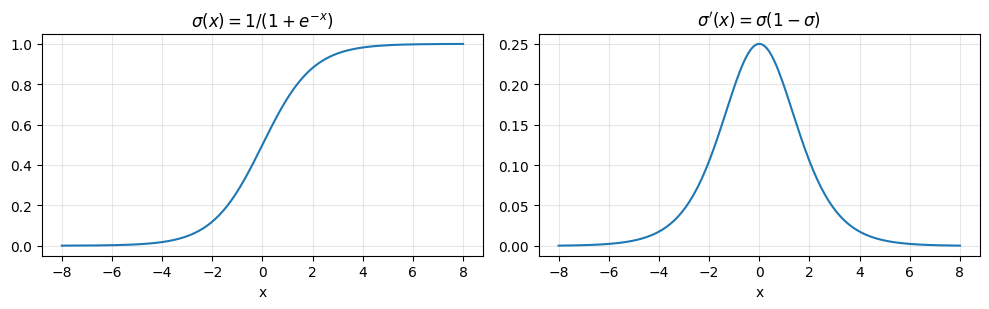

In [2]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_prime(z):
    s = sigmoid(z)
    return s * (1.0 - s)

x = np.linspace(-8, 8, 200)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(x, sigmoid(x));        ax[0].set_title(r"$\sigma(x)=1/(1+e^{-x})$"); ax[0].grid(alpha=.3)
ax[1].plot(x, sigmoid_prime(x));  ax[1].set_title(r"$\sigma'(x)=\sigma(1-\sigma)$"); ax[1].grid(alpha=.3)
for a in ax: a.set_xlabel("x")
plt.tight_layout(); plt.show()

In [3]:
# One neuron with 3 inputs
w = np.array([0.5, -1.2, 0.8])
b = 0.1
a_prev = np.array([1.0, 0.4, -0.7])
a = sigmoid(w @ a_prev + b)
print("neuron output a =", round(float(a), 4))

neuron output a = 0.3917


## 2. A network is a composition of layers (forward pass)

Stacking layers, the whole network is just function composition:

$$a^{4}=F(x)=f^{4}\!\big(f^{3}\!\big(f^{2}\!\big(f^{1}(x)\big)\big)\big).$$

With enough hidden units a network can approximate essentially any continuous function (**universal approximation**, Cybenko 1989) — that is the "high descriptive capacity" the lecture highlights. Below we run a forward pass through a small net with random weights.


In [4]:
def init_layers(sizes, seed=0):
    g = np.random.default_rng(seed)
    # weights[l]: shape (n_{l+1}, n_l);  biases[l]: shape (n_{l+1}, 1)
    weights = [g.normal(0, 1, (j, k)) * np.sqrt(1.0 / k) for k, j in zip(sizes[:-1], sizes[1:])]
    biases  = [np.zeros((j, 1)) for j in sizes[1:]]
    return weights, biases

def forward(weights, biases, a):
    zs, acts = [], [a]          # store pre-activations z and activations a for every layer
    for w, b in zip(weights, biases):
        z = w @ a + b
        zs.append(z)
        a = sigmoid(z)
        acts.append(a)
    return zs, acts

W, B = init_layers([3, 4, 2], seed=1)
x = np.array([[0.2], [-0.5], [0.9]])
_, acts = forward(W, B, x)
print("input shape", x.shape, "-> output", acts[-1].ravel().round(3))

input shape (3, 1) -> output [0.459 0.42 ]


## 3. Supervised learning & the cost function

We are given labelled examples $\{(x_1,y_1),\dots,(x_N,y_N)\}$. In the lecture's chest X-ray example the label is **one-hot**: normal $=[1,0]^\top$, COVID-19 $=[0,1]^\top$. Training means changing the weights and biases so the network output $a_x$ moves toward the target $y_x$. "How wrong are we" is measured by the **quadratic cost**

$$C(w,b)=\frac{1}{2N}\sum_{x=1}^{N}\lVert y_x-a_x\rVert_2^{2}.$$


In [5]:
def cost(weights, biases, X, Y):
    # X: (n_in, N), Y: (n_out, N)
    _, acts = forward(weights, biases, X)
    return 0.5 * np.mean(np.sum((Y - acts[-1])**2, axis=0))

## 4. Gradient descent: how we minimise the cost

The cost is a function of (many) parameters; we cannot solve $\nabla C=0$ in closed form, so we walk **downhill** along the negative gradient. For a single variable the update is

$$x_{i+1}=x_i-\alpha\,\frac{\partial f(x_i)}{\partial x_i},$$

where $\alpha$ is the **learning rate**. Below we minimise a 1-D bumpy function and watch the iterate slide into a local minimum — exactly the picture from the lecture. Note it finds a *local* (not necessarily global) minimum, which is why the starting point and $\alpha$ matter.


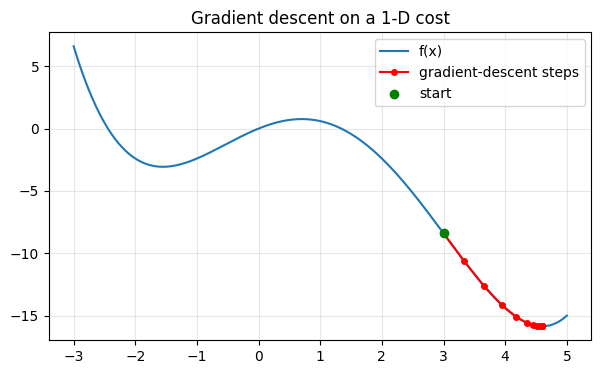

converged to x = 4.601


In [6]:
f      = lambda x: 0.1*x**4 - 0.5*x**3 - x**2 + 2*x
fprime = lambda x: 0.4*x**3 - 1.5*x**2 - 2*x + 2

xi, alpha, path = 3.0, 0.05, [3.0]
for _ in range(60):
    xi = xi - alpha * fprime(xi)
    path.append(xi)
path = np.array(path)

xs = np.linspace(-3, 5, 400)
plt.figure(figsize=(7, 4))
plt.plot(xs, f(xs), label="f(x)")
plt.plot(path, f(path), "r.-", ms=8, label="gradient-descent steps")
plt.scatter([path[0]], [f(path[0])], c="g", zorder=5, label="start")
plt.legend(); plt.grid(alpha=.3); plt.title("Gradient descent on a 1-D cost"); plt.show()
print("converged to x =", round(path[-1], 3))

## 5. Backpropagation from scratch — the four equations

Gradient descent needs $\partial C/\partial w$ and $\partial C/\partial b$ for **every** parameter. Backpropagation (Rumelhart, Hinton & Williams 1986) computes them efficiently by applying the chain rule layer by layer. Following the lecture, with $z^l=w^l a^{l-1}+b^l$, $a^l=\sigma(z^l)$ and $C_0=\tfrac12(y-a^L)^2$:

**Output layer**

$$\frac{\partial C_0}{\partial a^{L}}=a^{L}-y,\qquad
\frac{\partial a^{L}}{\partial z^{L}}=\sigma'(z^{L}),\qquad
\frac{\partial z^{L}}{\partial w^{L}}=a^{L-1},\qquad
\frac{\partial z^{L}}{\partial b^{L}}=1 .$$

Chaining them gives the output-layer gradients:

$$\boxed{\;\frac{\partial C_0}{\partial w^{L}}=a^{L-1}\,\sigma'(z^{L})\,(a^{L}-y),\qquad
\frac{\partial C_0}{\partial b^{L}}=\sigma'(z^{L})\,(a^{L}-y)\;}$$

**Recursing backwards** — the error is pushed to the previous layer through the weights:

$$\boxed{\;\frac{\partial C_0}{\partial a^{l}}=\sum_j w^{l+1}_{jk}\,\sigma'(z^{l+1})\,\frac{\partial C_0}{\partial a^{l+1}}\;}$$

and then $\partial C_0/\partial w^l$, $\partial C_0/\partial b^l$ use the same boxed formulas one layer down. Define $\delta^l=\sigma'(z^l)\,\partial C_0/\partial a^l$; then $\partial C_0/\partial b^l=\delta^l$, $\partial C_0/\partial w^l=\delta^l (a^{l-1})^\top$, and $\partial C_0/\partial a^{l-1}=(w^l)^\top\delta^l$. That is the whole algorithm.


In [7]:
def backprop(weights, biases, x, y):
    zs, acts = forward(weights, biases, x)            # forward pass, caching z and a
    gw = [np.zeros_like(w) for w in weights]
    gb = [np.zeros_like(b) for b in biases]

    dC_da = acts[-1] - y                              # dC0/da^L = a^L - y
    for l in range(len(weights) - 1, -1, -1):
        delta  = sigmoid_prime(zs[l]) * dC_da         # delta^l = sigma'(z^l) * dC0/da^l
        gb[l]  = delta                                # dC0/db^l = delta
        gw[l]  = delta @ acts[l].T                    # dC0/dw^l = delta (a^{l-1})^T
        dC_da  = weights[l].T @ delta                 # dC0/da^{l-1} = (w^l)^T delta
    return gw, gb

### 5.1 Sanity check: does backprop match the numerical gradient?

The single most useful debugging habit in deep learning. We perturb each weight by $\pm\varepsilon$, recompute the cost, and compare the finite-difference slope to what `backprop` returns. Agreement to ~$10^{-7}$ means our chain-rule code is correct.


In [8]:
def numerical_grad(weights, biases, x, y, eps=1e-6):
    grads = []
    for l in range(len(weights)):
        g = np.zeros_like(weights[l])
        for idx in np.ndindex(weights[l].shape):
            weights[l][idx] += eps; c1 = 0.5*np.sum((y - forward(weights, biases, x)[1][-1])**2)
            weights[l][idx] -= 2*eps; c2 = 0.5*np.sum((y - forward(weights, biases, x)[1][-1])**2)
            weights[l][idx] += eps
            g[idx] = (c1 - c2) / (2*eps)
        grads.append(g)
    return grads

Wc, Bc = init_layers([2, 4, 1], seed=3)
x = np.array([[0.5], [-0.3]]); y = np.array([[1.0]])
gw, _   = backprop(Wc, Bc, x, y)
gw_num  = numerical_grad(Wc, Bc, x, y)
err = max(np.max(np.abs(a - b)) for a, b in zip(gw, gw_num))
print(f"max |analytic - numerical| = {err:.2e}   (should be ~1e-7 or smaller)")

max |analytic - numerical| = 2.14e-11   (should be ~1e-7 or smaller)


## 6. Train the from-scratch MLP on toy 2-D data

We wrap forward/backprop into a small trainer (full-batch gradient descent, looping over training examples and averaging the gradients — exactly the "loop over training examples" slide) and learn the classic **two-moons** problem: not linearly separable, so it forces the network to use its hidden layer.


In [9]:
class MLP:
    # Sigmoid MLP trained with full-batch gradient descent on the quadratic cost.
    def __init__(self, sizes, seed=0):
        self.sizes = sizes
        self.weights, self.biases = init_layers(sizes, seed)

    def fit(self, X, Y, epochs=3000, lr=0.5, verbose=True):
        n = X.shape[1]; history = []
        for e in range(epochs):
            GW = [np.zeros_like(w) for w in self.weights]
            GB = [np.zeros_like(b) for b in self.biases]
            for i in range(n):                         # accumulate gradient over the data
                gw, gb = backprop(self.weights, self.biases, X[:, i:i+1], Y[:, i:i+1])
                for l in range(len(GW)): GW[l] += gw[l]; GB[l] += gb[l]
            self.weights = [w - lr*g/n for w, g in zip(self.weights, GW)]
            self.biases  = [b - lr*g/n for b, g in zip(self.biases,  GB)]
            c = cost(self.weights, self.biases, X, Y); history.append(c)
            if verbose and (e % (epochs//10) == 0 or e == epochs-1):
                print(f"epoch {e:5d}  cost {c:.4f}")
        return history

    def predict(self, X):
        return forward(self.weights, self.biases, X)[1][-1]

In [10]:
from sklearn.datasets import make_moons
Xraw, yraw = make_moons(n_samples=300, noise=0.20, random_state=0)
Xraw = (Xraw - Xraw.mean(0)) / Xraw.std(0)            # standardise inputs
X = Xraw.T                                            # (2, N)
Y = yraw.reshape(1, -1).astype(float)                # (1, N), targets in {0,1}

net = MLP([2, 16, 1], seed=1)
hist = net.fit(X, Y, epochs=3000, lr=1.0)

acc = ((net.predict(X) > 0.5).astype(int) == Y).mean()
print("training accuracy:", round(float(acc), 3))

epoch     0  cost 0.1158
epoch   300  cost 0.0472
epoch   600  cost 0.0444
epoch   900  cost 0.0404
epoch  1200  cost 0.0355
epoch  1500  cost 0.0306
epoch  1800  cost 0.0266
epoch  2100  cost 0.0236
epoch  2400  cost 0.0214
epoch  2700  cost 0.0197
epoch  2999  cost 0.0184
training accuracy: 0.97


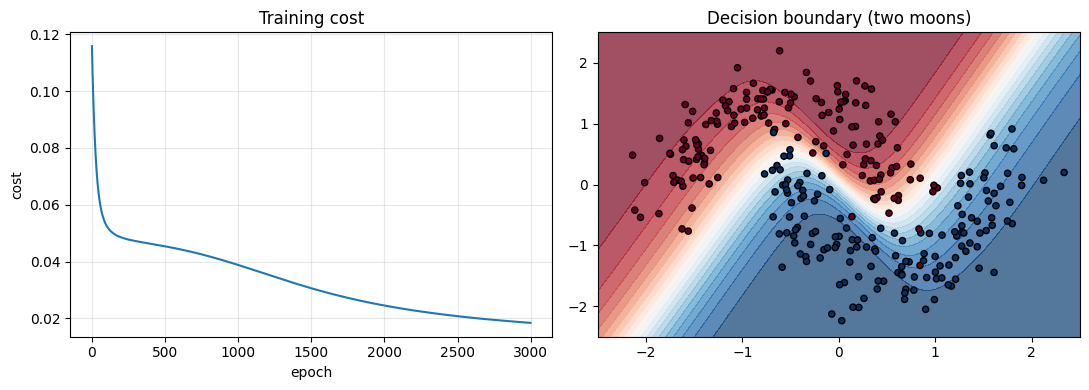

In [11]:
# Cost curve + learned decision boundary
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("cost"); ax[0].set_title("Training cost"); ax[0].grid(alpha=.3)

xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 200), np.linspace(-2.5, 2.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()].T
zz = net.predict(grid).reshape(xx.shape)
ax[1].contourf(xx, yy, zz, levels=20, cmap="RdBu", alpha=.7)
ax[1].scatter(Xraw[:, 0], Xraw[:, 1], c=yraw, cmap="RdBu", edgecolor="k", s=20)
ax[1].set_title("Decision boundary (two moons)")
plt.tight_layout(); plt.show()

## 7. The same network in PyTorch

Frameworks do the forward pass, store the computation graph, call `loss.backward()` (this is backprop / autograd), and update parameters with an optimiser. Notice how the from-scratch logic above maps one-to-one onto these few lines. We use cross-entropy here (the standard choice for classification) instead of the quadratic cost.


In [12]:
if HAS_TORCH:
    Xt = torch.tensor(Xraw, dtype=torch.float32)
    yt = torch.tensor(yraw, dtype=torch.long)

    model = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 2))
    opt   = torch.optim.Adam(model.parameters(), lr=0.05)
    lossf = nn.CrossEntropyLoss()

    for epoch in range(300):
        opt.zero_grad()
        loss = lossf(model(Xt), yt)
        loss.backward()          # <-- backpropagation (autograd)
        opt.step()
    acc = (model(Xt).argmax(1) == yt).float().mean().item()
    print(f"PyTorch MLP training accuracy: {acc:.3f}")
else:
    print("PyTorch not installed - skipping (the NumPy MLP above already demonstrates the idea).")

PyTorch MLP training accuracy: 0.980


## 8. Why convolutional networks? Count the parameters

Feed a $320\times320$ MR image into a **fully-connected** layer that maps $102{,}400$ pixels to $102{,}400$ outputs and you need

$$102400 \times 102400 \approx 1.05\times10^{10}$$

weights — for a single layer. That is wasteful: a pixel's meaning depends mostly on its neighbours, and the same feature (an edge, a blob) can appear anywhere. **CNNs** (LeCun 1989) exploit this with two ideas:

- **local connectivity** — each output looks only at a small patch, and
- **parameter sharing** — the *same* small filter slides across the whole image.

A single $3\times3$ convolution computes $w^\top x + b$ at every location and has only $3\cdot3+1=10$ parameters, independent of image size. Massively more efficient.


In [13]:
H = W_ = 320
fc_params   = (H*W_) * (H*W_)            # one fully-connected layer, image->image
conv_params = 3*3 + 1                     # one 3x3 filter (+bias)
print(f"fully-connected layer : {fc_params:.3e} parameters")
print(f"single 3x3 conv filter: {conv_params} parameters")
print(f"ratio                 : {fc_params/conv_params:.2e} x fewer with the conv filter")

fully-connected layer : 1.049e+10 parameters
single 3x3 conv filter: 10 parameters
ratio                 : 1.05e+09 x fewer with the conv filter


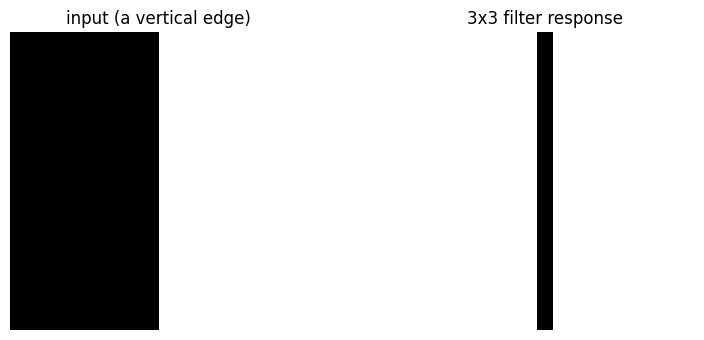

In [14]:
# A 3x3 convolution is just w^T x + b applied to every local patch.
# Here we apply a vertical-edge (Sobel) filter to a synthetic image to make 'local feature detection' concrete.
def conv2d_valid(img, kernel, bias=0.0):
    kh, kw = kernel.shape
    H, W = img.shape
    out = np.zeros((H - kh + 1, W - kw + 1))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            patch = img[i:i+kh, j:j+kw]
            out[i, j] = np.sum(patch * kernel) + bias        # w^T x + b
    return out

img = np.zeros((40, 40)); img[:, 20:] = 1.0                  # a vertical edge
sobel = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], float)
feat = conv2d_valid(img, sobel)

fig, ax = plt.subplots(1, 2, figsize=(8, 3.5))
ax[0].imshow(img, cmap="gray"); ax[0].set_title("input (a vertical edge)")
ax[1].imshow(feat, cmap="gray"); ax[1].set_title("3x3 filter response")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## 9. A simple CNN in PyTorch

A minimal classification CNN: a couple of conv layers (feature extraction with shared weights) followed by a small fully-connected head. We test it on toy $28\times28$ images of two shapes so it runs in seconds; the architecture is exactly what you'd scale up for the image-quality task in Exercise 2.


In [15]:
def make_shape_images(n=400, size=28, seed=0):
    "Two classes: filled disk (0) vs filled square (1), random position/size + noise."
    g = np.random.default_rng(seed)
    X = np.zeros((n, 1, size, size), dtype=np.float32); y = np.zeros(n, dtype=np.int64)
    yy, xx = np.mgrid[0:size, 0:size]
    for i in range(n):
        cls = i % 2; y[i] = cls
        cx, cy = g.integers(8, size-8, 2); r = g.integers(4, 7)
        if cls == 0:
            mask = (xx-cx)**2 + (yy-cy)**2 <= r**2
        else:
            mask = (np.abs(xx-cx) <= r) & (np.abs(yy-cy) <= r)
        img = mask.astype(np.float32) + 0.15*g.standard_normal((size, size)).astype(np.float32)
        X[i, 0] = img
    return X, y

if HAS_TORCH:
    Xnp, ynp = make_shape_images(400, seed=1)
    Xc = torch.tensor(Xnp); yc = torch.tensor(ynp)
    ntr = 320
    Xtr, ytr, Xte, yte = Xc[:ntr], yc[:ntr], Xc[ntr:], yc[ntr:]

    class SmallCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 28->14
                nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 14->7
                nn.Flatten(),
                nn.Linear(16*7*7, 32), nn.ReLU(), nn.Linear(32, 2))
        def forward(self, x): return self.net(x)

    cnn = SmallCNN()
    opt = torch.optim.Adam(cnn.parameters(), lr=1e-3)
    lossf = nn.CrossEntropyLoss()
    for epoch in range(15):
        perm = torch.randperm(ntr)
        for b in range(0, ntr, 32):
            idx = perm[b:b+32]
            opt.zero_grad(); loss = lossf(cnn(Xtr[idx]), ytr[idx]); loss.backward(); opt.step()
    with torch.no_grad():
        acc = (cnn(Xte).argmax(1) == yte).float().mean().item()
    n_params = sum(p.numel() for p in cnn.parameters())
    print(f"CNN test accuracy: {acc:.3f}   |   total parameters: {n_params:,}")
else:
    print("PyTorch not installed - skipping the CNN demo.")

CNN test accuracy: 0.800   |   total parameters: 26,434


---
# Exercises

The lecture closes with two application exercises. Below are **self-contained tasks** (data is synthesised to resemble the lecture's examples so nothing needs downloading) with `# TODO` skeletons. Try them yourself first; **fully worked solutions are at the end of the notebook**.


## Exercise 1 — Classification of brain tissue from DTI features

The lecture classifies brain tissue from Human Connectome Project DTI data. Each voxel is a feature vector
$$x_i=[\,\mathrm{T1w}_i,\ \mathrm{FA}_i,\ \mathrm{MD}_i,\ \mathrm{AD}_i,\ \mathrm{RD}_i\,]$$
and the label is the tissue class (Thalamus = GM, corpus callosum = highly-aligned WM, cortical WM, ...). We generate synthetic voxels around the representative values from the lecture's table.

**Your tasks**
1. Standardise the features (why is this important for sigmoid networks?).
2. One-hot encode the 3 labels and split train/test.
3. Train the from-scratch `MLP` (architecture `[5, H, 3]`) **and** a PyTorch model.
4. Report test accuracy and a confusion matrix.


In [16]:
# --- provided: synthetic DTI dataset (means/units taken from the lecture's table) ---
def make_dti_dataset(n_per_class=200, seed=0):
    g = np.random.default_rng(seed)
    # [T1w(a.u.), FA(-), MD, AD, RD]   (diffusivities in um^2/ms)
    means = {0: [898, 0.22, 1.07, 1.33, 0.94],   # Thalamus (GM)
             1: [1007, 0.68, 0.39, 0.72, 0.22],  # Corpus callosum (aligned WM)
             2: [867, 0.38, 0.58, 0.82, 0.45]}   # Cortical WM
    stds  = [60, 0.07, 0.12, 0.15, 0.10]
    names = ["Thalamus", "Corpus callosum", "Cortical WM"]
    X, y = [], []
    for cls, m in means.items():
        for _ in range(n_per_class):
            X.append([g.normal(mi, si) for mi, si in zip(m, stds)]); y.append(cls)
    return np.array(X), np.array(y), names

X_dti, y_dti, class_names = make_dti_dataset()
print("X:", X_dti.shape, " y:", y_dti.shape, " classes:", class_names)

# TODO 1: standardise X_dti  ->  Xn
# TODO 2: one-hot encode y_dti -> Y_oh (shape (N, 3)); shuffle & split into train/test
# TODO 3: train MLP([5, 16, 3]) on the transposed arrays (features-by-samples)
# TODO 4: compute test accuracy and a 3x3 confusion matrix

X: (600, 5)  y: (600,)  classes: ['Thalamus', 'Corpus callosum', 'Cortical WM']


## Exercise 2 — Classifying image quality of accelerated reconstructions (CNN)

The lecture's second example: given a reconstructed image, decide whether it is a **fully-sampled** reference or a **4× accelerated** reconstruction (which can be blurry / lose information, per the Knoll 2011 knee images). We synthesise smooth "phantom" images and degrade half of them to mimic acceleration artifacts, then train a CNN to tell them apart.

**Your tasks**
1. Inspect a few good vs degraded images.
2. Build a small CNN (`Conv → ReLU → Pool → ... → Linear`).
3. Train and report test accuracy.
4. *Reflection:* what visual cues might the network be using, and why is a CNN a better fit here than a fully-connected net?


In [17]:
# --- provided: synthetic 'fully sampled' vs 'accelerated' image dataset ---
def make_quality_dataset(n=400, size=32, seed=0):
    g = np.random.default_rng(seed)
    X = np.zeros((n, 1, size, size), dtype=np.float32); y = np.zeros(n, dtype=np.int64)
    yy, xx = np.mgrid[0:size, 0:size]
    for i in range(n):
        # random smooth phantom: a few overlapping blobs
        img = np.zeros((size, size), dtype=np.float32)
        for _ in range(g.integers(3, 6)):
            cx, cy = g.uniform(0, size, 2); r = g.uniform(4, 9)
            img += np.exp(-((xx-cx)**2 + (yy-cy)**2) / (2*r**2))
        img = img / (img.max() + 1e-8)
        if i % 2 == 1:                      # class 1 = 'accelerated': blur + aliasing-like noise
            y[i] = 1
            k = np.ones((3, 3), np.float32) / 9.0
            blur = conv2d_valid(np.pad(img, 1, mode="edge"), k)     # cheap 3x3 box blur, same size
            img = blur + 0.06 * g.standard_normal((size, size)).astype(np.float32)
            img[:, ::4] += 0.05            # faint periodic (undersampling-like) pattern
        else:
            y[i] = 0                         # class 0 = 'fully sampled'
        X[i, 0] = img.astype(np.float32)
    return X, y

X_q, y_q = make_quality_dataset()
print("images:", X_q.shape, " labels:", np.bincount(y_q))

# TODO 1: plot 3 fully-sampled (y==0) and 3 accelerated (y==1) images side by side
# TODO 2: build a small CNN (reuse the SmallCNN pattern; input is 32x32 here)
# TODO 3: train on 80% / test on 20%; print test accuracy
# TODO 4: write 2-3 sentences answering the reflection question

images: (400, 1, 32, 32)  labels: [200 200]


---
# Solutions

Spoilers below. Try the exercises first!


### Solution 1 — DTI tissue classification

In [18]:
# 1. Standardise: sigmoid saturates for large |z|; features on very different scales
#    (T1w ~ 900 vs FA ~ 0.3) would dominate the weighted sum, so zero-mean/unit-var helps.
mu, sd = X_dti.mean(0), X_dti.std(0)
Xn = (X_dti - mu) / sd

# 2. One-hot + shuffle + split
Y_oh = np.eye(3)[y_dti]                       # (N, 3)
perm = rng.permutation(len(Xn))
Xn, Y_oh, y_sh = Xn[perm], Y_oh[perm], y_dti[perm]
ntr = int(0.8 * len(Xn))
Xtr, Ytr = Xn[:ntr].T, Y_oh[:ntr].T          # transpose -> (features, samples)
Xte, Yte = Xn[ntr:].T, Y_oh[ntr:].T
yte_int  = y_sh[ntr:]

# 3a. From-scratch MLP
net_dti = MLP([5, 16, 3], seed=2)
net_dti.fit(Xtr, Ytr, epochs=1500, lr=0.8, verbose=False)
pred = np.argmax(net_dti.predict(Xte), axis=0)
print("NumPy MLP test accuracy:", round(float((pred == yte_int).mean()), 3))

# 4. Confusion matrix
cm = np.zeros((3, 3), int)
for t, p in zip(yte_int, pred): cm[t, p] += 1
print("\nconfusion matrix (rows = true, cols = pred):")
print("            " + "  ".join(f"{n[:6]:>6}" for n in class_names))
for i, n in enumerate(class_names):
    print(f"{n:>14} " + "  ".join(f"{v:6d}" for v in cm[i]))

NumPy MLP test accuracy: 1.0

confusion matrix (rows = true, cols = pred):
            Thalam  Corpus  Cortic
      Thalamus     45       0       0
Corpus callosum      0      36       0
   Cortical WM      0       0      39


In [19]:
# 3b. Same task in PyTorch
if HAS_TORCH:
    Xtr_t = torch.tensor(Xtr.T, dtype=torch.float32); ytr_t = torch.tensor(y_sh[:ntr])
    Xte_t = torch.tensor(Xte.T, dtype=torch.float32); yte_t = torch.tensor(yte_int)
    clf = nn.Sequential(nn.Linear(5, 16), nn.ReLU(), nn.Linear(16, 3))
    opt = torch.optim.Adam(clf.parameters(), lr=0.05); lossf = nn.CrossEntropyLoss()
    for _ in range(400):
        opt.zero_grad(); lossf(clf(Xtr_t), ytr_t).backward(); opt.step()
    acc = (clf(Xte_t).argmax(1) == yte_t).float().mean().item()
    print(f"PyTorch MLP test accuracy: {acc:.3f}")
else:
    print("PyTorch not installed - NumPy result above stands.")

PyTorch MLP test accuracy: 1.000


### Solution 2 — Image-quality classification (CNN)

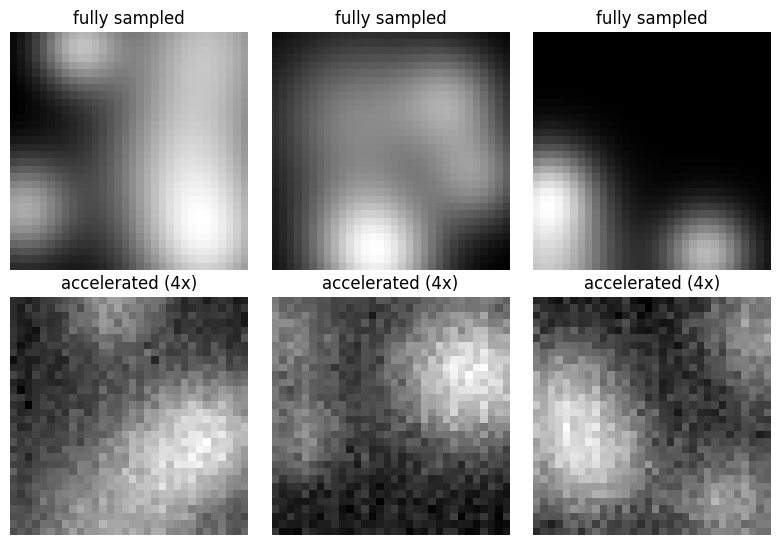

In [20]:
# 1. Visualise good vs degraded
good = np.where(y_q == 0)[0][:3]; bad = np.where(y_q == 1)[0][:3]
fig, ax = plt.subplots(2, 3, figsize=(8, 5.5))
for j, idx in enumerate(good):
    ax[0, j].imshow(X_q[idx, 0], cmap="gray"); ax[0, j].set_title("fully sampled"); ax[0, j].axis("off")
for j, idx in enumerate(bad):
    ax[1, j].imshow(X_q[idx, 0], cmap="gray"); ax[1, j].set_title("accelerated (4x)"); ax[1, j].axis("off")
plt.tight_layout(); plt.show()

In [21]:
# 2-3. CNN classifier
if HAS_TORCH:
    Xc = torch.tensor(X_q); yc = torch.tensor(y_q)
    perm = torch.randperm(len(Xc)); Xc, yc = Xc[perm], yc[perm]
    ntr = int(0.8 * len(Xc))
    Xtr, ytr, Xte, yte = Xc[:ntr], yc[:ntr], Xc[ntr:], yc[ntr:]

    class QualityCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),    # 32->16
                nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 16->8
                nn.Flatten(), nn.Linear(16*8*8, 32), nn.ReLU(), nn.Linear(32, 2))
        def forward(self, x): return self.net(x)

    cnn = QualityCNN(); opt = torch.optim.Adam(cnn.parameters(), lr=1e-3); lossf = nn.CrossEntropyLoss()
    for epoch in range(20):
        p = torch.randperm(ntr)
        for b in range(0, ntr, 32):
            idx = p[b:b+32]
            opt.zero_grad(); lossf(cnn(Xtr[idx]), ytr[idx]).backward(); opt.step()
    with torch.no_grad():
        acc = (cnn(Xte).argmax(1) == yte).float().mean().item()
    print(f"Quality-CNN test accuracy: {acc:.3f}")
else:
    print("PyTorch not installed - skipping CNN training.")

Quality-CNN test accuracy: 1.000


**4. Reflection.** The degraded class differs from the reference through *local* texture cues — blurring of fine edges, added noise, and a faint periodic (aliasing-like) pattern. A CNN is well suited because these cues are local and can appear anywhere in the image, so **weight sharing** lets one small filter detect them everywhere while keeping the parameter count tiny. A fully-connected net would need a separate weight for every pixel-to-pixel connection (the $\sim10^{10}$ blow-up from §8), would ignore spatial structure, and would need far more data to generalise. This mirrors the lecture's point that for image inputs, convolutional layers are a far more efficient use of parameters.


---
## Recap

- A neuron is $a=\sigma(w^\top a^{-} + b)$; a network is a composition of such layers with high descriptive capacity.
- **Training** = minimise a cost $C(w,b)$ by **gradient descent**: $\theta \leftarrow \theta - \alpha\,\partial C/\partial\theta$.
- **Backpropagation** is the efficient chain-rule recursion for those derivatives — and we verified our implementation against numerical gradients.
- For images, **CNNs** (local connectivity + weight sharing) replace the parameter explosion of fully-connected layers.
- We applied both to MRI-flavoured tasks: DTI tissue classification (MLP) and accelerated-reconstruction quality control (CNN).

**Next (C11):** using these networks for *MR image reconstruction* itself — learned priors and unrolled networks that reconstruct from undersampled k-space.
